In [52]:
import tenpy
import sys
sys.path.append('..')

import set_size_helper as ssh
from tenpy.networks.mps import TransferMatrix
import src.observables as obs
import utils.io as io
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import re, glob
import pandas as pd
print(f"TeNPy version: {tenpy.__version__}")
import matplotlib as mpl
mpl.style.use("aps.mplstyle")
DATA_ROOT = '../../data/iDMRG/'

TeNPy version: 1.1.0


/scratch/ashankar/Spin1LongRangeOrder.jl/python/figmaker/set_size_helper.py:2: SyntaxWarning: invalid escape sequence '\c'
  """
/scratch/ashankar/Spin1LongRangeOrder.jl/python/figmaker/set_size_helper.py:29: SyntaxWarning: invalid escape sequence '\c'
  """


In [4]:
loadfile = os.path.join(DATA_ROOT, "Vpm4.350cc/Vpm_4.350_chi1000.h5")
psi, results = io.load_mps_with_metadata(loadfile)
print('Correlation length = ', psi.correlation_length2())
diags = results["diagnostics"]
diags.keys()

Correlation length =  383.86783251469706


dict_keys(['Delta_E', 'Delta_S', 'E', 'N_updates', 'S', 'max_E_trunc', 'max_S', 'max_chi', 'max_trunc_err', 'norm_err', 'sweep', 'time'])

#### Schmidt values from entanglement spectrum $H_i$
$$ \lambda_i = \exp{(-H_i)} $$
The schmidt values are $\sqrt{\lambda_i}$
#### Entanglement entropy defined as 
$$ S_{ent} = -\sum_i \lambda_i\log\lambda_i  = \sum_{i}H_i\exp{(-H_i)} $$


In [ ]:
ent_spec = psi.entanglement_spectrum()
print("EE = ", psi.entanglement_entropy())
print([np.sum(np.exp(-es)*es) for es in ent_spec]) 
evs, _ = TransferMatrix(psi, psi).eigenvectors(num_ev=100)

EE =  [1.92329543 1.92329559 1.92329523 1.92329534]


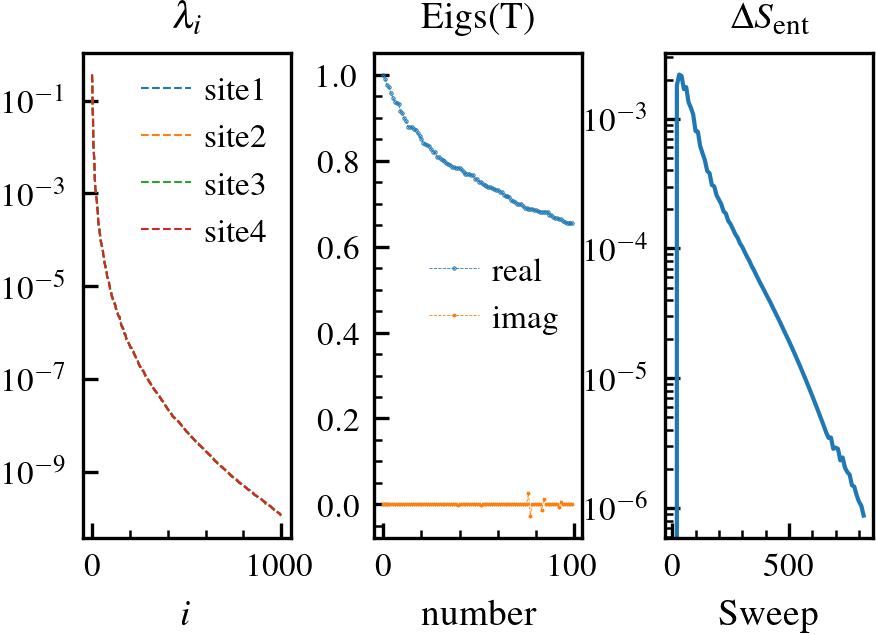

In [55]:
fig, ax = plt.subplots(1,3)
fig_width = ssh.set_size(width_pt=246*1.5, fraction=1./3, subplots=(1,3))
fig.subplots_adjust(wspace=0.4)
for i in [0,1,2,3]:
    lambdai = np.exp(-np.array(ent_spec))[i]
    ax[0].plot(lambdai, ls='--', marker='', ms=0.5, lw=0.5, label=f'site{i+1}')

ax[0].set_yscale('log')
ax[0].legend()
ax[0].set_xlabel(r'$i$')
ax[0].set_title(r'$\lambda_i$')


# ax[1].plot(diags['max_trunc_err'])
ax[1].plot(evs.real, marker='.', ls='--', lw=0.2, label='real', ms=0.5)
ax[1].plot(evs.imag, marker='*', ls='--', lw=0.2, label='imag', ms=0.5)
ax[1].legend()
ax[1].set_yscale('linear')
ax[1].set_xlabel(r'number')
ax[1].set_title(r'Eigs(T)')

ax[2].plot(diags['sweep'], diags['Delta_S'])
ax[2].set_xlabel(r'Sweep')
ax[2].set_title(r'$\Delta S_{\mathrm{ent}}$')
ax[2].set_yscale('log')

fig.savefig('figures/dmrg_diagnostics.pdf', bbox_inches='tight')